In [2]:
import pandas as pd
import kagglehub

# Download dataset
path = kagglehub.dataset_download("utkarshx27/smoking-dataset-from-uk")

# Load manually
df = pd.read_csv(path + "/smoking.csv")

print(df.head())

   Unnamed: 0  gender  age marital_status highest_qualification nationality  \
0           1    Male   38       Divorced      No Qualification     British   
1           2  Female   42         Single      No Qualification     British   
2           3    Male   40        Married                Degree     English   
3           4  Female   40        Married                Degree     English   
4           5  Female   39        Married          GCSE/O Level     British   

  ethnicity      gross_income     region smoke  amt_weekends  amt_weekdays  \
0     White    2,600 to 5,200  The North    No           NaN           NaN   
1     White       Under 2,600  The North   Yes          12.0          12.0   
2     White  28,600 to 36,400  The North    No           NaN           NaN   
3     White  10,400 to 15,600  The North    No           NaN           NaN   
4     White    2,600 to 5,200  The North    No           NaN           NaN   

      type  
0      NaN  
1  Packets  
2      NaN  
3   

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1691 entries, 0 to 1690
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1691 non-null   int64  
 1   gender                 1691 non-null   str    
 2   age                    1691 non-null   int64  
 3   marital_status         1691 non-null   str    
 4   highest_qualification  1691 non-null   str    
 5   nationality            1691 non-null   str    
 6   ethnicity              1691 non-null   str    
 7   gross_income           1691 non-null   str    
 8   region                 1691 non-null   str    
 9   smoke                  1691 non-null   str    
 10  amt_weekends           421 non-null    float64
 11  amt_weekdays           421 non-null    float64
 12  type                   421 non-null    str    
dtypes: float64(2), int64(2), str(9)
memory usage: 171.9 KB


In [4]:
df.describe()

,Unnamed: 0,age,amt_weekends,amt_weekdays
count,1691.000000,1691.000000,421.000000,421.000000
mean,846.000000,49.836192,16.410926,13.750594
std,488.293969,18.736851,9.892988,9.388292
min,1.000000,16.000000,0.000000,0.000000
25%,423.500000,34.000000,10.000000,7.000000
50%,846.000000,48.000000,15.000000,12.000000
75%,1268.500000,65.500000,20.000000,20.000000
max,1691.000000,97.000000,60.000000,55.000000


In [5]:
df.isnull().sum()

Unnamed: 0                  0
gender                      0
age                         0
marital_status              0
highest_qualification       0
nationality                 0
ethnicity                   0
gross_income                0
region                      0
smoke                       0
amt_weekends             1270
amt_weekdays             1270
type                     1270
dtype: int64

In [6]:
df.dropna() # hadling missing value


,Unnamed: 0,gender,age,marital_status,highest_qualification,nationality,ethnicity,gross_income,region,smoke,amt_weekends,amt_weekdays,type
1,2,Female,42,Single,No Qualification,British,White,"Under 2,600",The North,Yes,12.0,12.0,Packets
6,7,Male,53,Married,Degree,British,White,"Above 36,400",The North,Yes,6.0,6.0,Packets
8,9,Male,40,Single,GCSE/CSE,English,White,"2,600 to 5,200",The North,Yes,8.0,8.0,Hand-Rolled
9,10,Female,41,Married,No Qualification,English,White,"5,200 to 10,400",The North,Yes,15.0,12.0,Packets
20,21,Female,34,Married,GCSE/CSE,British,White,"2,600 to 5,200",The North,Yes,6.0,12.0,Packets
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1674,1675,Female,31,Single,GCSE/O Level,Scottish,White,"15,600 to 20,800",Scotland,Yes,20.0,10.0,Packets
1680,1681,Male,24,Single,No Qualification,Scottish,White,"Under 2,600",Scotland,Yes,15.0,15.0,Hand-Rolled
1683,1684,Male,35,Married,No Qualification,Scottish,White,"10,400 to 15,600",Scotland,Yes,3.0,12.0,Packets
1687,1688,Female,49,Divorced,Other/Sub Degree,English,White,"2,600 to 5,200",Scotland,Yes,20.0,20.0,Hand-Rolled


In [7]:
df.drop_duplicates()


,Unnamed: 0,gender,age,marital_status,highest_qualification,nationality,ethnicity,gross_income,region,smoke,amt_weekends,amt_weekdays,type
0,1,Male,38,Divorced,No Qualification,British,White,"2,600 to 5,200",The North,No,NaN,NaN,NaN
1,2,Female,42,Single,No Qualification,British,White,"Under 2,600",The North,Yes,12.0,12.0,Packets
2,3,Male,40,Married,Degree,English,White,"28,600 to 36,400",The North,No,NaN,NaN,NaN
3,4,Female,40,Married,Degree,English,White,"10,400 to 15,600",The North,No,NaN,NaN,NaN
4,5,Female,39,Married,GCSE/O Level,British,White,"2,600 to 5,200",The North,No,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,1687,Male,22,Single,No Qualification,Scottish,White,"2,600 to 5,200",Scotland,No,NaN,NaN,NaN
1687,1688,Female,49,Divorced,Other/Sub Degree,English,White,"2,600 to 5,200",Scotland,Yes,20.0,20.0,Hand-Rolled
1688,1689,Male,45,Married,Other/Sub Degree,Scottish,White,"5,200 to 10,400",Scotland,No,NaN,NaN,NaN
1689,1690,Female,51,Married,No Qualification,English,White,"2,600 to 5,200",Scotland,Yes,20.0,20.0,Packets


In [8]:
df['smoke'].value_counts()

smoke
No     1270
Yes     421
Name: count, dtype: int64

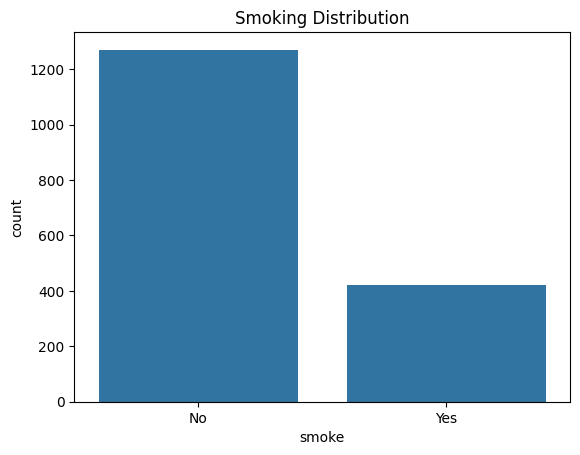

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='smoke', data=df)
plt.title("Smoking Distribution")

plt.savefig("smoking_distribution.png", dpi=300, bbox_inches='tight')  # 🔥 save here
plt.show()

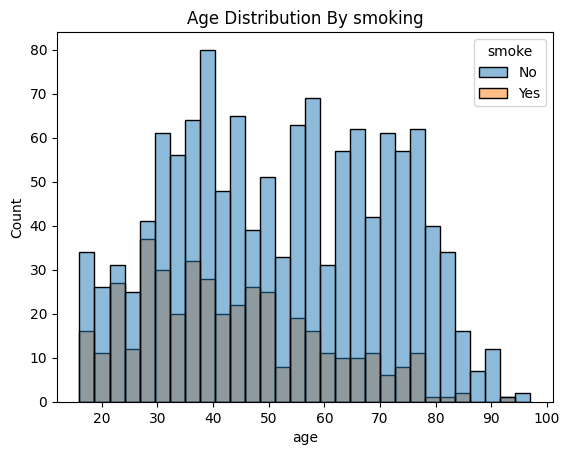

In [10]:
sns.histplot(data=df, x='age', hue='smoke', bins=30)
plt.title("Age Distribution By smoking")
plt.savefig("age_distribution_by_somking.png", dpi=300, bbox_inches='tight' )
plt.show()


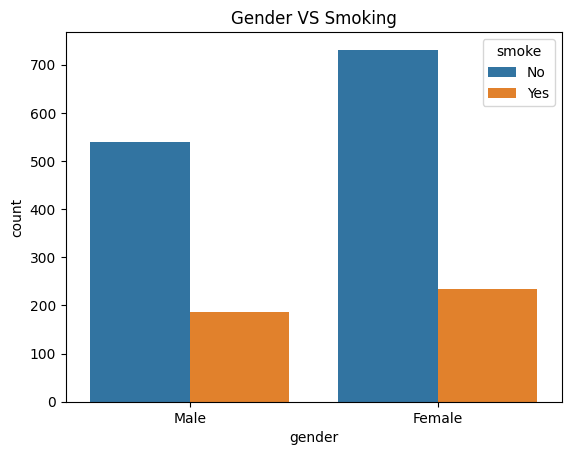

In [11]:
# gender vs somking analysis
sns.countplot(data=df, x='gender', hue='smoke')
plt.title("Gender VS Smoking")
plt.savefig("gender_vs_smoking.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
df.columns


Index(['Unnamed: 0', 'gender', 'age', 'marital_status',
       'highest_qualification', 'nationality', 'ethnicity', 'gross_income',
       'region', 'smoke', 'amt_weekends', 'amt_weekdays', 'type'],
      dtype='str')

In [13]:
df.columns

Index(['Unnamed: 0', 'gender', 'age', 'marital_status',
       'highest_qualification', 'nationality', 'ethnicity', 'gross_income',
       'region', 'smoke', 'amt_weekends', 'amt_weekdays', 'type'],
      dtype='str')

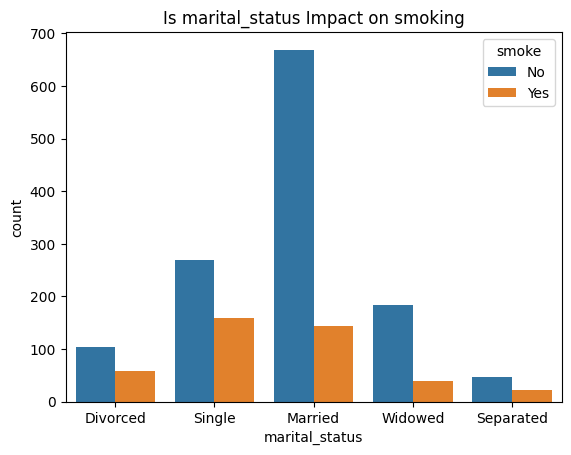

In [14]:
#marital_status vs smoking
sns.countplot(data=df, x='marital_status', hue='smoke')
plt.title("Is marital_status Impact on smoking")
plt.savefig('marital_status_vs_smoking.png', dpi=300, bbox_inches='tight')
plt.show()

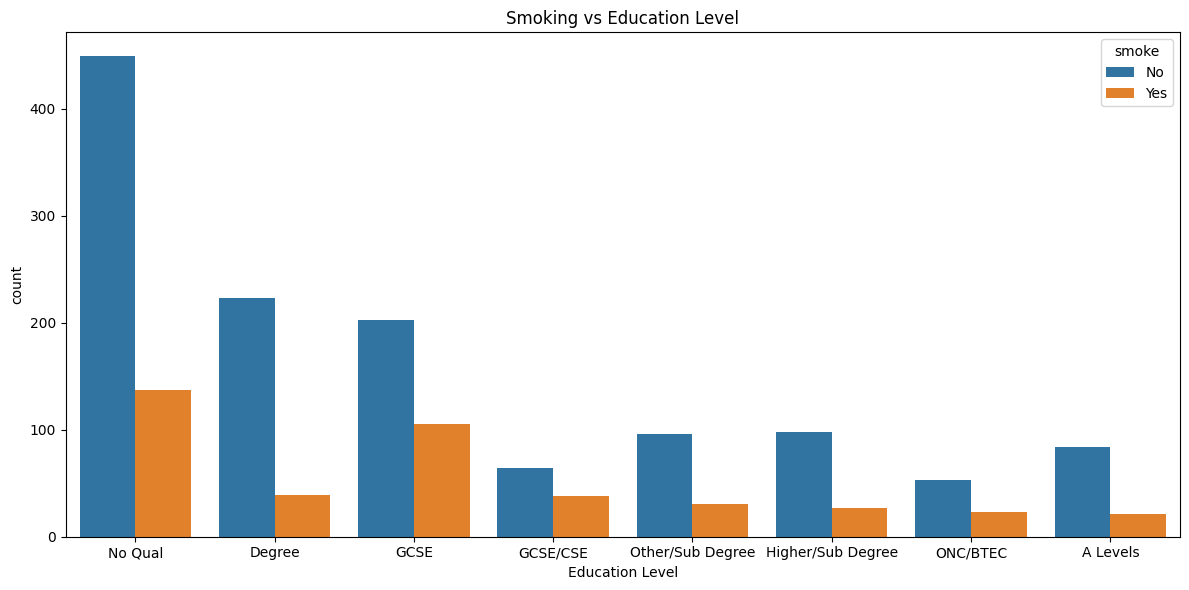

In [15]:

df['qualification_short'] = df['highest_qualification'].replace({
    'No Qualification': 'No Qual',
    'GCSE/O Level': 'GCSE',
    'A Levels/BTEC': 'A-Level',
    'Bachelor Degree': 'Bachelor',
    'Postgraduate': 'Postgrad'
})

plt.figure(figsize=(12,6))

sns.countplot(data=df, x='qualification_short', hue='smoke')

plt.xticks(rotation=0)
plt.title("Smoking vs Education Level")
plt.xlabel("Education Level")

plt.tight_layout()
plt.savefig('Education_impact_on_smoking.png')
plt.show()

In [16]:
df.columns

Index(['Unnamed: 0', 'gender', 'age', 'marital_status',
       'highest_qualification', 'nationality', 'ethnicity', 'gross_income',
       'region', 'smoke', 'amt_weekends', 'amt_weekdays', 'type',
       'qualification_short'],
      dtype='str')

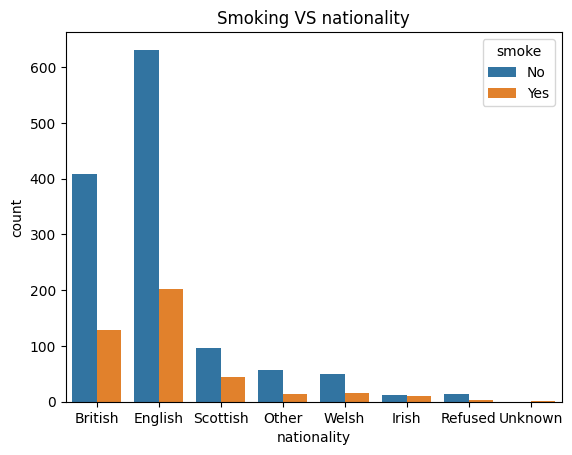

In [17]:
sns.countplot(data=df, x='nationality', hue='smoke')
plt.title('Smoking VS nationality')
plt.savefig('smoking_vs_nationality.png', dpi=300, bbox_inches='tight')
plt.show()

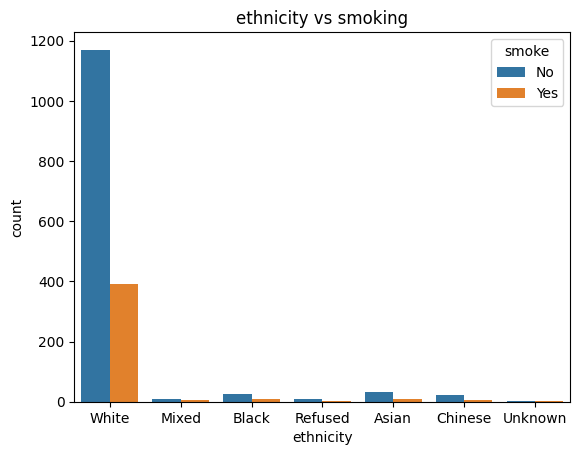

In [18]:
sns.countplot(data=df, x='ethnicity', hue='smoke')
plt.title('ethnicity vs smoking')
plt.savefig('ethnicity_vs_smoking.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
df.columns

Index(['Unnamed: 0', 'gender', 'age', 'marital_status',
       'highest_qualification', 'nationality', 'ethnicity', 'gross_income',
       'region', 'smoke', 'amt_weekends', 'amt_weekdays', 'type',
       'qualification_short'],
      dtype='str')

In [20]:
df.head()

,Unnamed: 0,gender,age,marital_status,highest_qualification,nationality,ethnicity,gross_income,region,smoke,amt_weekends,amt_weekdays,type,qualification_short
0,1,Male,38,Divorced,No Qualification,British,White,"2,600 to 5,200",The North,No,NaN,NaN,NaN,No Qual
1,2,Female,42,Single,No Qualification,British,White,"Under 2,600",The North,Yes,12.0,12.0,Packets,No Qual
2,3,Male,40,Married,Degree,English,White,"28,600 to 36,400",The North,No,NaN,NaN,NaN,Degree
3,4,Female,40,Married,Degree,English,White,"10,400 to 15,600",The North,No,NaN,NaN,NaN,Degree
4,5,Female,39,Married,GCSE/O Level,British,White,"2,600 to 5,200",The North,No,NaN,NaN,NaN,GCSE


In [21]:
df.columns

Index(['Unnamed: 0', 'gender', 'age', 'marital_status',
       'highest_qualification', 'nationality', 'ethnicity', 'gross_income',
       'region', 'smoke', 'amt_weekends', 'amt_weekdays', 'type',
       'qualification_short'],
      dtype='str')

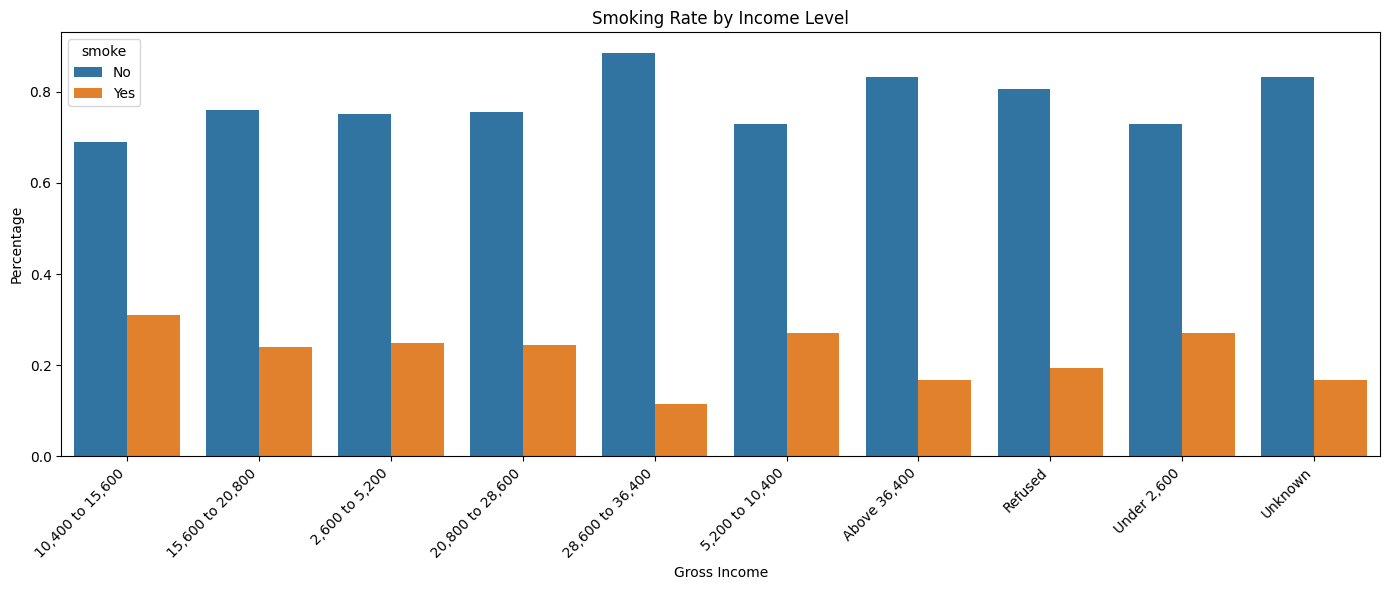

In [22]:
# Normalize data (percentage of smokers per income group)
income_smoke = (
    df.groupby(['gross_income', 'smoke'])
    .size()
    .reset_index(name='count')
)

# Convert to percentage
income_smoke['percent'] = income_smoke.groupby('gross_income')['count']\
                                      .transform(lambda x: x / x.sum())

plt.figure(figsize=(14,6))

sns.barplot(
    data=income_smoke,
    x='gross_income',
    y='percent',
    hue='smoke'
)

plt.xticks(rotation=45, ha='right')
plt.title("Smoking Rate by Income Level")
plt.ylabel("Percentage")
plt.xlabel("Gross Income")

plt.tight_layout()
plt.savefig("smoking_rate_by_income_level.png")
plt.show()